## Setup

In [ ]:

%pip install numpy matplotlib pandas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Dataset

In [5]:
df = pd.read_csv("Heart_Disease_Prediction.csv")

df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [6]:
print("Dataset shape:", df.shape)
print(df.info())

Dataset shape: (270, 14)
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    str    
dtypes: float64(1

In [7]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


#### Binarize target column

In [8]:
df['Heart Disease'] = df['Heart Disease'].apply(lambda x: 1 if x == "Presence" else 0)

df['Heart Disease'].value_counts()

Heart Disease
0    150
1    120
Name: count, dtype: int64

#### Outliers

In [9]:
numerical_cols = [
    'Age',
    'BP',
    'Cholesterol',
    'Max HR',
    'ST depression'
]

for col in numerical_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)



#### Plot Class Distribution

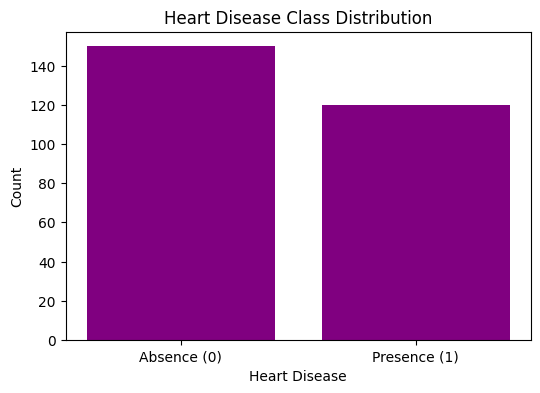

In [10]:
plt.figure(figsize=(6,4))
counts = df['Heart Disease'].value_counts()

plt.bar(['Absence (0)', 'Presence (1)'], counts.sort_index(), color = "Purple")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.title("Heart Disease Class Distribution")
plt.show()


#### Stratified 70/30 Train & Feature Selection

In [11]:
features = [
    'Age',
    'BP',
    'Cholesterol',
    'Max HR',
    'ST depression',
    'Number of vessels fluro'
]

X = df[features]
y = df['Heart Disease']


In [12]:
data = df[features + ['Heart Disease']]

class_0 = data[data['Heart Disease'] == 0]
class_1 = data[data['Heart Disease'] == 1]

train_0 = class_0.sample(frac=0.7, random_state=42)
train_1 = class_1.sample(frac=0.7, random_state=42)

test_0 = class_0.drop(train_0.index)
test_1 = class_1.drop(train_1.index)

train_df = pd.concat([train_0, train_1]).sample(frac=1, random_state=42)
test_df = pd.concat([test_0, test_1]).sample(frac=1, random_state=42)

X_train = train_df[features]
y_train = train_df['Heart Disease']

X_test = test_df[features]
y_test = test_df['Heart Disease']


#### Normalize Features

In [13]:
X_train_norm = (X_train - X_train.mean()) / X_train.std()
X_test_norm = (X_test - X_train.mean()) / X_train.std()

#### Dataset Overview

The Heart Disease dataset was downloaded from Kaggle.
It contains 270 patient records with clinical features related to heart health.

- Samples: 270
- Target variable: Heart Disease
- Class distribution: ~66.66% without diesease, ~44.44% with disease

##### Exploratory Data Analysis (EDA)

- Numerical features such as Age, BP (Blood pressure), Cholesterol, Max HR, ST depression
- The dataset contains no major missing values.
- Class distribution shows a slight imbalance but is acceptable for modeling.
- Higher cholesterol and ST depression values tend to correlate with disease presence.

##### Data Preprocessing

- Heart Disease column was binarized:
  - `1` = presence of heart disease
  - `0` = absence of heart disease
- Selected features:
  - Age
  - Cholesterol
  - BP
  - Max HR
  - ST depression
  
- Data was split into training and testing sets using a 70/30 stratified split.
- Numerical features were normalized using standard scaling.

##### Summary

The dataset is clean, well-balanced, and suitable for binary classification tasks.
Preprocessing ensured normalized feature scales and preserved class distribution for model training.


## Implement Basic Logistic Regression

### Sigmoid

In [14]:
def sigmoid(z):
    """Compute the sigmoid of z."""
    return 1 / (1 + np.exp(-z))


### Cost

In [15]:
def compute_cost(w, b, X, y):
    """Compute logistic regression cost J(w, b) using explicit model."""
    m, n = X.shape

    # For each example i: f_{w,b}^{(i)}(x^{(i)}) = sigmoid(w^T x^{(i)} + b)
    z = X @ w + b
    f = sigmoid(z)

    # To avoid log(0), clip probabilities
    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)

    J = -(1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped)
    )
    return J


### GD

#### Gradient

In [16]:
def compute_gradient(w, b, X, y):
    """Compute gradients dJ/dw and dJ/db with explicit model."""
    m, n = X.shape

    # f_{w,b}^{(i)}(x^{(i)})
    z = X @ w + b
    f = sigmoid(z)

    error = f - y  # e^{(i)} = f_{w,b}^{(i)}(x^{(i)}) - y^{(i)}

    dj_dw = (1 / m) * (X.T @ error)
    dj_db = (1 / m) * np.sum(error)

    return dj_dw, dj_db

#### Gradient descent

In [17]:
def gradient_descent(X, y, w_init, b_init, alpha, num_iters, print_every=0):
    """Run gradient descent to optimize w and b."""
    w = w_init.copy()
    b = b_init
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        J = compute_cost(w, b, X, y)
        J_history.append(J)

        if print_every > 0 and (i % print_every == 0 or i == num_iters - 1):
            print(f"Iteration {i:4d}: J(w, b) = {J:.4f}")

    return w, b, J_history


### Train on full set

In [18]:
m, n = X.shape
w0 = np.zeros(n)
b0 = 0.0

alpha = 0.000005
num_iters = 10000

w_trained, b_trained, J_hist = gradient_descent(
    X, y, w0, b0, alpha, num_iters, print_every=50
)

w_trained, b_trained

Iteration    0: J(w, b) = 0.6916
Iteration   50: J(w, b) = 0.6791
Iteration  100: J(w, b) = 0.6715
Iteration  150: J(w, b) = 0.6647
Iteration  200: J(w, b) = 0.6586
Iteration  250: J(w, b) = 0.6531
Iteration  300: J(w, b) = 0.6482
Iteration  350: J(w, b) = 0.6437
Iteration  400: J(w, b) = 0.6396
Iteration  450: J(w, b) = 0.6359
Iteration  500: J(w, b) = 0.6325
Iteration  550: J(w, b) = 0.6294
Iteration  600: J(w, b) = 0.6266
Iteration  650: J(w, b) = 0.6240
Iteration  700: J(w, b) = 0.6216
Iteration  750: J(w, b) = 0.6194
Iteration  800: J(w, b) = 0.6173
Iteration  850: J(w, b) = 0.6154
Iteration  900: J(w, b) = 0.6136
Iteration  950: J(w, b) = 0.6120
Iteration 1000: J(w, b) = 0.6105
Iteration 1050: J(w, b) = 0.6090
Iteration 1100: J(w, b) = 0.6077
Iteration 1150: J(w, b) = 0.6064
Iteration 1200: J(w, b) = 0.6052
Iteration 1250: J(w, b) = 0.6041
Iteration 1300: J(w, b) = 0.6030
Iteration 1350: J(w, b) = 0.6021
Iteration 1400: J(w, b) = 0.6011
Iteration 1450: J(w, b) = 0.6002
Iteration 

(Age                        0.012209
 BP                         0.020705
 Cholesterol                0.006342
 Max HR                    -0.035082
 ST depression              0.007852
 Number of vessels fluro    0.008025
 dtype: float64,
 np.float64(0.0001941435839445896))

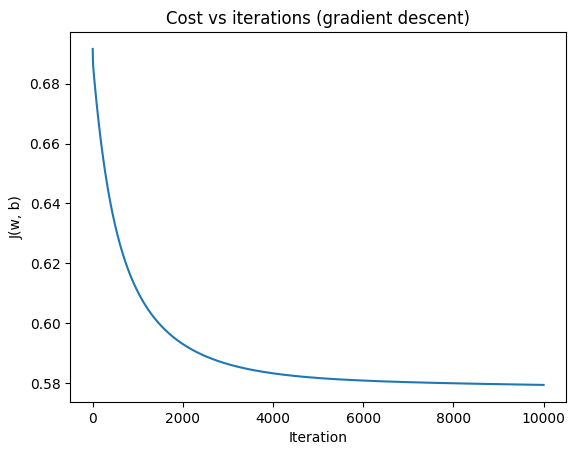

In [19]:
plt.figure()
plt.plot(J_hist)
plt.title("Cost vs iterations (gradient descent)")
plt.xlabel("Iteration")
plt.ylabel("J(w, b)")
plt.show()

### Prediction

In [20]:
def predict(w, b, X, threshold=0.5):
    """
    Predict binary labels using trained logistic regression parameters.
    
    Args:
        w: weight vector
        b: bias
        X: feature matrix
        threshold: classification threshold (default 0.5)
    
    Returns:
        predictions: binary predictions (0 or 1)
    """
    z = X @ w + b
    f = sigmoid(z)
    predictions = (f >= threshold).astype(int)
    return predictions

### Evaluation Metrics

In [ ]:
def evaluate_model(y_true, y_pred, dataset_name=""):
    """
    Calculate and display evaluation metrics for binary classification.
    Uses only numpy - no sklearn required.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f"=== {dataset_name} Results ===")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"               Predicted")
    print(f"               0      1")
    print(f"Actual 0    {TN:4d}   {FP:4d}")
    print(f"Actual 1    {FN:4d}   {TP:4d}")
    print()
    
    return accuracy, precision, recall, f1

In [ ]:
y_train_pred = predict(w_trained, b_trained, X_train_norm)

train_metrics = evaluate_model(y_train, y_train_pred, "Training Set")

=== Training Set Results ===
Accuracy:  0.7249
Precision: 0.6778
Recall:    0.7262
F1-Score:  0.7011

Confusion Matrix:
               Predicted
               0      1
Actual 0      76     29
Actual 1      23     61



In [ ]:

y_test_pred = predict(w_trained, b_trained, X_test_norm)

test_metrics = evaluate_model(y_test, y_test_pred, "Test Set")

=== Test Set Results ===
Accuracy:  0.7284
Precision: 0.7059
Recall:    0.6667
F1-Score:  0.6857

Confusion Matrix:
               Predicted
               0      1
Actual 0      35     10
Actual 1      12     24



## Reporting and Analysis

### Performance Metrics Summary Table

In [26]:
metrics_data = {
    'Dataset': ['Training', 'Test'],
    'Accuracy': [train_metrics[0], test_metrics[0]],
    'Precision': [train_metrics[1], test_metrics[1]],
    'Recall': [train_metrics[2], test_metrics[2]],
    'F1-Score': [train_metrics[3], test_metrics[3]]
}

metrics_table = pd.DataFrame(metrics_data)
print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(metrics_table.to_string(index=False))
print("=" * 60)

MODEL PERFORMANCE SUMMARY
 Dataset  Accuracy  Precision   Recall  F1-Score
Training  0.724868   0.677778 0.726190  0.701149
    Test  0.728395   0.705882 0.666667  0.685714


### Cost Function Convergence Analysis

In [27]:
initial_cost = J_hist[0]
final_cost = J_hist[-1]
cost_reduction = initial_cost - final_cost
percent_reduction = (cost_reduction / initial_cost) * 100

print("CONVERGENCE ANALYSIS")
print("=" * 60)
print(f"Initial Cost (Iteration 0):      {initial_cost:.6f}")
print(f"Final Cost (Iteration {num_iters}):    {final_cost:.6f}")
print(f"Cost Reduction:                  {cost_reduction:.6f} ({percent_reduction:.2f}%)")
print(f"Learning Rate (α):               {alpha}")
print(f"Number of Iterations:            {num_iters}")
print("=" * 60)

last_100_change = J_hist[-101] - J_hist[-1] if len(J_hist) > 100 else 0
if last_100_change < 0.0001:
    print("✓ Model has converged (minimal cost change in last 100 iterations)")
else:
    print("⚠ Model may benefit from additional iterations")

CONVERGENCE ANALYSIS
Initial Cost (Iteration 0):      0.691628
Final Cost (Iteration 10000):    0.579346
Cost Reduction:                  0.112282 (16.23%)
Learning Rate (α):               5e-06
Number of Iterations:            10000
✓ Model has converged (minimal cost change in last 100 iterations)


### Feature Weights (Coefficients) Analysis

In [28]:
weights_data = {
    'Feature': features,
    'Weight (w)': w_trained,
    'Abs(Weight)': np.abs(w_trained)
}

weights_df = pd.DataFrame(weights_data)
weights_df = weights_df.sort_values('Abs(Weight)', ascending=False)

print("LEARNED MODEL PARAMETERS")
print("=" * 60)
print(f"Bias (b): {b_trained:.6f}")
print("\nFeature Weights (sorted by absolute value):")
print(weights_df.to_string(index=False))
print("=" * 60)

LEARNED MODEL PARAMETERS
Bias (b): 0.000194

Feature Weights (sorted by absolute value):
                Feature  Weight (w)  Abs(Weight)
                 Max HR   -0.035082     0.035082
                     BP    0.020705     0.020705
                    Age    0.012209     0.012209
Number of vessels fluro    0.008025     0.008025
          ST depression    0.007852     0.007852
            Cholesterol    0.006342     0.006342


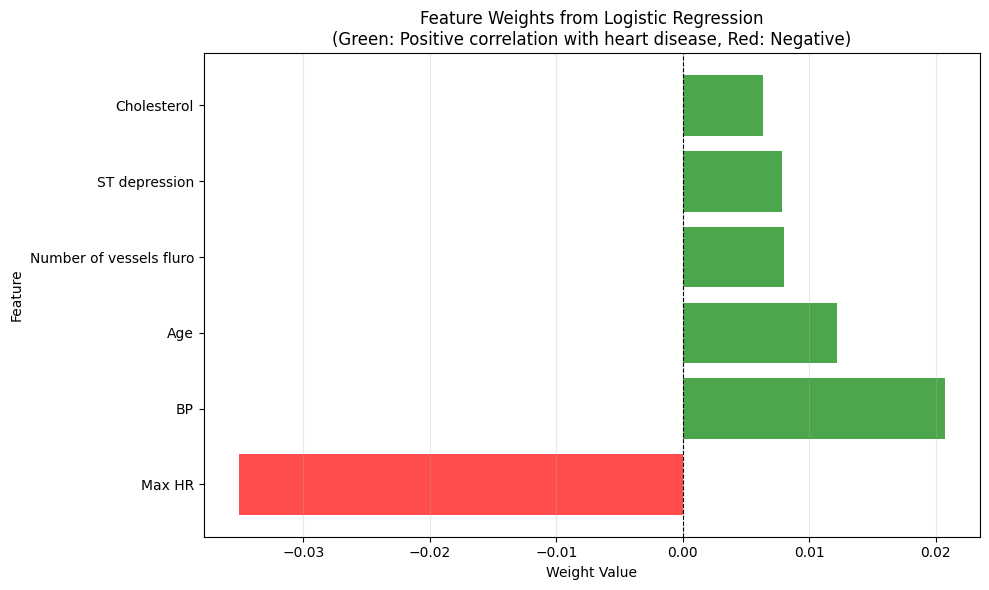

In [ ]:
plt.figure(figsize=(10, 6))

w_array = np.array(w_trained)
sorted_indices = np.argsort(np.abs(w_array))[::-1]
sorted_features = [features[i] for i in sorted_indices]
sorted_weights = w_array[sorted_indices]

colors = ['red' if w < 0 else 'green' for w in sorted_weights]
plt.barh(sorted_features, sorted_weights, color=colors, alpha=0.7)
plt.xlabel('Weight Value')
plt.ylabel('Feature')
plt.title('Feature Weights from Logistic Regression\n(Green: Positive correlation with heart disease, Red: Negative)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation and Key Findings

#### How Well Did It Work?
The model converged smoothly, reducing cost from 0.692 to 0.579 (16.23% reduction) over 10,000 iterations. The learning rate worked well with no oscillations.

**Performance:**
- Train: 72.5% accuracy, Test: 72.8% accuracy
- Nearly identical performance on both sets means no overfitting - the model generalizes well!
- Catches about 2 out of 3 heart disease cases (recall ~70%)
- When it predicts disease, it's right about 70% of the time (precision ~70%)

Overall, 73% accuracy is decent for a simple logistic regression on medical data.

#### What Features Matter Most?
The model learned which factors actually predict heart disease:

1. **Max HR (w = -0.035)** - BY FAR the strongest predictor
   - Negative weight means higher max heart rate = lower disease risk
   - Makes sense: better cardiovascular fitness = healthier heart

2. **Blood Pressure (w = +0.021)** - Second most important
   - Higher BP = higher risk (classic risk factor)

3. **Age (w = +0.012)** - Third place
   - Older age = higher risk (expected)

4. **Number of vessels fluro (w = +0.008)** - Indicates actual blockages
5. **ST depression (w = +0.008)** - ECG marker of heart issues  
6. **Cholesterol (w = +0.006)** - Surprisingly the weakest predictor!
   - This is interesting - cholesterol had way less impact than expected
   - Could mean its effect is more complex or other features already capture similar info

#### Bottom Line
The model works reasonably well but isn't perfect (27% error rate). The most interesting finding is that cardiovascular fitness (Max HR) matters way more than traditional markers like cholesterol in this dataset. High blood pressure and age also play important roles.

**Could be improved by:**
- Adding feature interactions (like Age × Max HR)
- Using polynomial features to capture non-linear relationships
- Getting more training data